# Reconstructing a Gaussian Splat Radiance Field and High Quality Mesh from a Capture 
----
In this notebook, we'll walk through how to reconstruct a Gaussian Splat radiance field, and high quality triangle mesh from an input drone capture. The capture consists of a collection of posed images along with sparse points.  We'll show how you can visualize this radiance field interactively in a notebook or browser, how to save the radiance field to common formats like PLY and USDZ, and how to use the radiance field to construct a high quality triangle mesh. Along the way, we'll get a tour of the basic components of the `fvdb_reality_capture` library.

The notebook walks through a common reality capture pipeline like in the figure below:
<img src="https://fvdb-data.s3.us-east-2.amazonaws.com/fvdb-reality-capture/meshing_med.gif"
       alt="Reality Capture Pipeline"
       style="display: block; margin-left: auto; margin-right: auto; width: 100%; margin-top: -4em; margin-bottom: -2em" />

## Setup and imports

Before we get started, let's import the pacakges we need. Here's an overview of some of the important ones:

* `logging`
    - We'll use the built-in Python `logging` module, and call `logging.basicConfig()` which will cause functions within `fvdb_reality_capture` to log to stdout. You don't have to enable this, but it's useful to see what's happening under the hood.
* `fvdb` 
    - We use `fvdb` for the underlying Gaussian splat data structure (`fvdb.GaussianSplat3d`) which provides fast and scalable rendering, and for interactive visualization (using the `fvdb.viz`) module.
* `fvdb_reality_capture` 
    - We use this for core algorithms that reconstruct scenes from sensors help us read and process capture data (Duh!)


In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import logging

import cv2
import fvdb
import matplotlib.pyplot as plt
import numpy as np
import torch

import fvdb_reality_capture as frc

# Let's use verbose logging to track what happens under the hood.
# For less output set level=logging.WARN. For more set level=logging.DEBUG
logging.basicConfig(level=logging.INFO, format="%(levelname)s : %(message)s")

# Initialize the fvdb.viz module for interactive 3D visualization.
# This will spin up a small HTTP server in the background.
fvdb.viz.init(port=8080)

Viewer Info: Running in headless mode - no GLFW window created


Viewer Info: Render loop started

Viewer Info: Server created on port(8080)
Viewer Info: Running on server 127.0.0.1:8080


## Download some example data
Let's download some example data to run on. We'll use the *"safety_park"* example dataset. This dataset is the output of a [COLMAP](https://colmap.github.io/) structure from motion pipeline on a sequence of images captured by a drone.

It contains posed images (i.e. images + the position and orientation of the camera that took them), camera intrinsic parameters (focal length, optical centers, etc.), and a set of sparse 3D points at known surfaces in the scene.

In [3]:
# Download example data for running splats on
frc.tools.download_example_data(dataset="safety_park", download_path="./data")

2026-01-13 10:09:02,210 - fvdb_reality_capture.tools._download_example_data.download_example_data - WARNING - Dataset directory data/safety_park already exists. Skipping download.


## Load our dataset into an `SfmScene` for reconstruction

Reality capture is the process of creating digital 3D representations of real-world scenes from sensor data, like images and LiDAR. To represent captured sensor data, `fvdb_reality_capture`  makes use of the `SfmScene` class, which is a lightweight handle to sensor data stored on disk. `SfmScene` offers a wide range of features for efficiently transforming large-scale datasets, some of which we'll see below. For a detailed tutorial, see the [Loading and Manipulating Sensor Data](https://openvdb.github.io/fvdb-reality-capture/tutorials/sensor_data_loading_and_manipulation.html) tutorial. 

An `SfmScene` consists of the following parts representing a scene captured with sensors:
 1. A list of **Posed images**. 
    - Images with camera-to-world/world-to-camera transformations specifying where each image was taken in the scene, and the identifier of the camera that captured them.
 2. A set of **Camera sensors**.
    - Information such as camera intrinsics and distortion parameters for each camera used to capture the scene. 
    - *Note the number of cameras is not the same as the number of posed images. If you captured 1000 images with a robot that had two cameras, there will be two cameras and 1000 posed images*
 2. A  set of **Scanned 3D points** 
    - These are points for which we have high confidence lie on a surface in the scene.
 3. An (optional) **Point visibility map**
    - These define the set of points visible within each posed image.

This type of sensor data may arise from capture hardware (_e.g._ a set of cameras and LiDAR sensors equipped with [Inertial Measurement Units (IMU)](https://en.wikipedia.org/wiki/Inertial_measurement_unit) sensors), or [from Structure-from-Motion (Sfm)](https://en.wikipedia.org/wiki/Structure_from_motion) capture which solves for camera poses and points using correspondences between a set of images. `fvdb_reality_capture` aims to support loading a wide variety of capture data formats into an `SfmScene`.

Let's load our downloaded dataset into an `SfmScene` and visualize it. We'll visualize the 3D points and cameras interactively using `fvdb.viz` and we'll plot some images with their visible points using `matplotlib`. The `fvdb.viz` module provides a high performance debug visualizer written in [vulkan](https://www.vulkan.org/). It spins up a small HTTP server which streams a visualization to a notebook or a browser.

2026-01-13 10:09:05,333 - fvdb_reality_capture.sfm_scene._load_colmap_scene.load_colmap_scene - INFO - Loading visible points per image from cache...


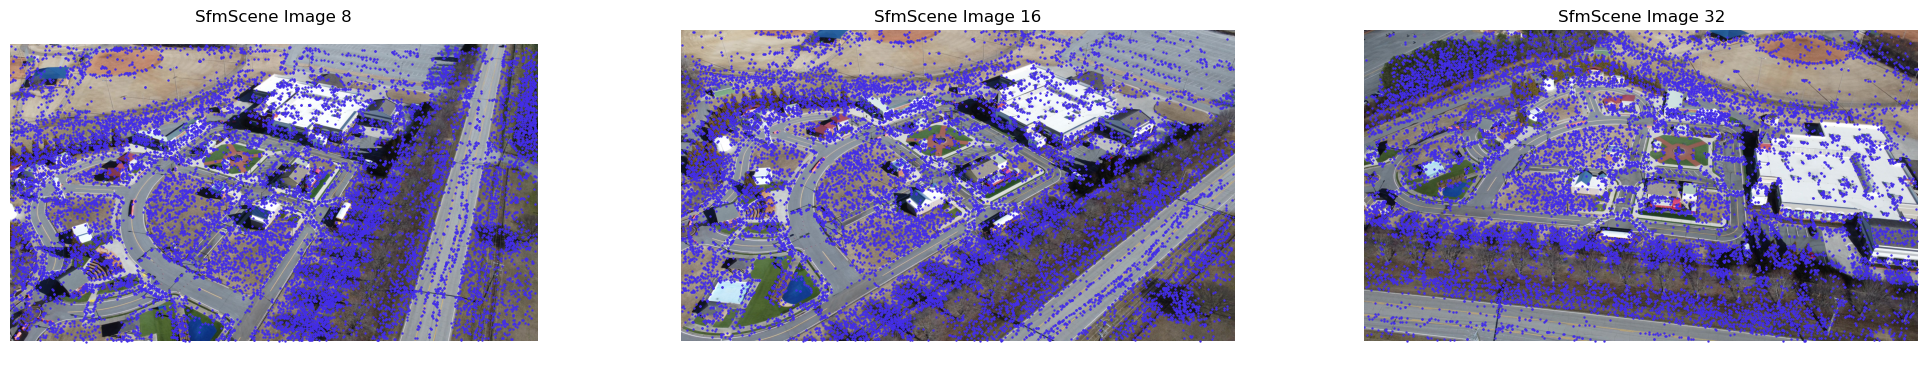

Viewer Info: Render loop stopped

Viewer Info: Running in headless mode - no GLFW window created
Viewer Info: Render loop started

Viewer Info: Server created on port(8080)
Viewer Info: Running on server 127.0.0.1:8080


In [4]:
dataset_path = "./data/safety_park"
sfm_scene = frc.sfm_scene.SfmScene.from_colmap(dataset_path)

# Visualize an image in an SfmScene and the 3D points visible from that images
# projected onto the image plane as blue dots.
def plot_image_from_scene(scene: frc.sfm_scene.SfmScene, image_id: int):
    image_meta: frc.sfm_scene.SfmPosedImageMetadata = scene.images[image_id]
    camera_meta: frc.sfm_scene.SfmCameraMetadata = image_meta.camera_metadata

    # Get the visible 3d points for this image
    visible_points_3d: np.ndarray = scene.points[image_meta.point_indices]

    # Project those points onto the image plane
    # 1. Get the world -> camera space transform and projection matrix
    world_to_cam_matrix: np.ndarray = image_meta.world_to_camera_matrix
    projection_matrix: np.ndarray = camera_meta.projection_matrix
    # 2. Transform world points to camera space
    visible_points_3d_cam_space = world_to_cam_matrix[:3,:3] @ visible_points_3d.T + world_to_cam_matrix[:3,3:4]
    # 3. Transform camera space coordinates to image space
    visible_points_2d = projection_matrix @ visible_points_3d_cam_space
    visible_points_2d /= visible_points_2d[2]

    # Load the image and convert to RGB (OpenCV uses BGR by default)
    loaded_image = cv2.imread(image_meta.image_path)
    assert loaded_image is not None, f"Failed to load image at {image_meta.image_path}"
    loaded_image = cv2.cvtColor(loaded_image, cv2.COLOR_BGR2RGB)

    # Plot the image and projected points
    plt.title(f"SfmScene Image {image_id}")
    plt.axis("off")
    plt.imshow(loaded_image)
    plt.scatter(visible_points_2d[0], visible_points_2d[1], color="#432de9", marker=".", s=2)

# Visualize the SfmScene interactively in a 3D viewer using fvdb.viz.Viewer
def visualize_sfm_scene(scene: frc.sfm_scene.SfmScene,
                        name: str,
                        center_scene: bool = False):

    viewer_scene = fvdb.viz.get_scene("SfmScene Visualization")
    viewer_scene.reset()
    # Optionally center the scene at the origin.
    # This is useful to visualize multiple scenes together without them being far apart.
    if center_scene:
        center_transform = np.eye(4)
        center_transform[:3, 3] = -np.median(scene.points, axis=0)
        scene = scene.apply_transformation_matrix(center_transform)

    # Plot the points in the SfmScene with their colors (which are uint8 by default but the viewer
    # expects float32 colors in [0,1]).
    # Each point is drawn as a small sphere with a 2 pixel radius.
    viewer_scene.add_point_cloud(
        name=f"{name} Points",
        points=scene.points,
        colors=scene.points_rgb.astype(np.float32) / 255.0,
        point_size=2.0)

    # Plot the cameras as coordinate frames with axis length 2 units,
    # and frustums whose distance from the origin to camera plane is 1 unit long.
    viewer_scene.add_cameras(
        f"{name} Cameras",
        camera_to_world_matrices=scene.camera_to_world_matrices,
        projection_matrices=scene.projection_matrices,
        axis_length=2,
        frustum_scale=2.5,
    )

    # Set the initial camera view to be at the position of the first posed image, in the SfmScene,
    # looking at the center of the 3D points, with Z as up (COLMAP SfM scenes use Z as up).
    viewer_scene.set_camera_lookat(
        eye=scene.image_camera_positions[0],
        center=np.zeros(3),
        up=np.array([0, 0, 1]),  # Z is up in COLMAP SfM scenes
    )


# Plot three images from the scene and their visible 3D points alongside each other
plt.figure(figsize=(25, 4.25))
plt.subplot(1, 3, 1)
plot_image_from_scene(sfm_scene, 8)
plt.subplot(1, 3, 2)
plot_image_from_scene(sfm_scene, 16)
plt.subplot(1, 3, 3)
plot_image_from_scene(sfm_scene, 32)
plt.show()

# View the SfmScene interactively in a 3D viewer
visualize_sfm_scene(sfm_scene, "Raw SfmScene", center_scene=True)
fvdb.viz.show()

You may have noticed the scene in the viewer is rotated with respect to the canonical axes. It's also very noisy with a lot of outlier points.
This is because the structure-from-motion algorithm which produced this data had a lot of noisy predictions, and predicted points and cameras in a rotated coordinate frame.
Before we reconstruct a Gaussian Splat radiance field, let's clean up our input data a bit. We'll apply the following steps:

 1. Downsample the images by a factor of 4 to speed up Gaussian Splat optimization (loading big images can be time consuming), 
 2. Normalize the scene to a canonical coordinte space by rotating it to align with the principle axes of the point cloud (thus correcting the up-axis).
 3. Remove outlier points below the bottom 3rd and above top 97th percentiles along the X, Y, and Z, axis.
 4. Remove any images with fewer than 50 visible points (these images are likely to have bad pose estimates)

`fvdb_reality_capture` makes this kind of cleanup easy, efficient, and seamless using the `transforms` module. 
Transforms are classes which define a transformation of an `SfmScene`. They inherit from `fvdb_reality_capture.BaseTransform`, and their `__call__` operator accepts an `SfmScene` as input and produces a new `SfmScene` as output. Let's look at some code and visualizations and then dive into how this works.

In [10]:
import fvdb_reality_capture.transforms as fvtransforms

# Clean up and resize the SfmScene using a transform pipeline which downsamples images,
# aligns the scene with its principle axes and centers it at (0, 0, 0),
# filters outlier points, and removes images with too few points.
cleanup_and_resize_transform = fvtransforms.Compose(
    fvtransforms.DownsampleImages(image_downsample_factor=4, image_type="jpg", rescaled_jpeg_quality=95),
    fvtransforms.NormalizeScene(normalization_type="pca"),
    fvtransforms.PercentileFilterPoints(percentile_min=3.0, percentile_max=97.0),
    fvtransforms.FilterImagesWithLowPoints(min_num_points=50),
)
cleaned_sfm_scene = cleanup_and_resize_transform(sfm_scene)

print(f"Original scene had {len(sfm_scene.points)} points and {len(sfm_scene.images)} images")
print(f"Cleaned scene has {len(cleaned_sfm_scene.points)} points and {len(cleaned_sfm_scene.images)} images")

# Visualize the transformed scene so we can see the effect of the cleanup and resizing
# Note that we don't have to center the scene here since the normalization transform already did that.
visualize_sfm_scene(cleaned_sfm_scene, "Cleaned SfmScene", center_scene=False)
print ( cleaned_sfm_scene._cache.cache_root_path, cleaned_sfm_scene._cache.current_folder_path)

2026-01-13 10:13:53,106 - fvdb_reality_capture.transforms.downsample_images.DownsampleImages - INFO - Rescaling images using downsample factor 4, sampling mode 3, and quality 95.
2026-01-13 10:13:53,107 - fvdb_reality_capture.transforms.downsample_images.DownsampleImages - INFO - Attempting to load downsampled images from cache.
2026-01-13 10:13:53,184 - fvdb_reality_capture.transforms.normalize_scene.NormalizeScene - INFO - Normalizing SfmScene with normalization type: pca
2026-01-13 10:13:53,200 - fvdb_reality_capture.transforms.percentile_filter_points.PercentileFilterPoints - INFO - Filtering points based on percentiles: min=[3. 3. 3.], max=[97. 97. 97.]


Original scene had 199702 points and 124 images
Cleaned scene has 168661 points and 124 images
Viewer Info: Render loop stopped

Viewer Info: Running in headless mode - no GLFW window created
Viewer Info: Render loop started

Viewer Info: Server created on port(8080)
Viewer Info: Running on server 127.0.0.1:8080
data/safety_park/_cache/cache_1 data/safety_park/_cache/cache_1/downsampled_4x_jpg_q95_m3


Note how the cleaned up scene has fewer noisy points and is aligned with the coordinate axes of the viewer.

In the code above, we defined our cleanup operation as a sequence of transformations, using the `Compose` transform, which composes a sequence of transforms into a single one. The composed transform runs the following in order:

 1. `DownsampleImages(4)` to downsample each image in the dataset by a factor of 4
 2. `NormalizeScene('pca')` to center the scene about its mean and rotate it to align with its principle axes.
 3. `PercentileFilterPoints(percentile_min=3.0, percentile_max=97.0)` to remove points in the bottom 3rd and top 97th percentiles along each axis.
 4. `FilterImagesWithLowPoints(min_num_points=50)` to remove posed images which have 50 or viewer visible points.

**Note:** `fvdb_reality_capture` provides more transforms and also lets you define your own transforms. See the API reference for `fvdb_reality_capture.transforms` and the the [Loading and Manipulating Sensor Data](https://openvdb.github.io/fvdb-reality-capture/tutorials/sensor_data_loading_and_manipulation.html) tutorial for more details.

**Note:** The `fvdb_reality_capture.transforms` module does not modify the underlying dataset that you pass in or store transformed data in memory.
Instead, it uses a cache which lets each transform cache intermediate results. This keeps `SfmScene`s lightweight and immutable, and 
lets you transform your data in a clean and non-destructive way.
To see the caching in action, remark how the first transformation took a while. If we run the process again, it's almost instantaneous due to caching.




In [7]:
# The transform pipeline caches results so re-applying it is very fast
%time cleaned_sfm_scene = cleanup_and_resize_transform(sfm_scene)

2026-01-13 10:11:46,964 - fvdb_reality_capture.transforms.downsample_images.DownsampleImages - INFO - Rescaling images using downsample factor 4, sampling mode 3, and quality 95.
2026-01-13 10:11:46,964 - fvdb_reality_capture.transforms.downsample_images.DownsampleImages - INFO - Attempting to load downsampled images from cache.
2026-01-13 10:11:47,040 - fvdb_reality_capture.transforms.normalize_scene.NormalizeScene - INFO - Normalizing SfmScene with normalization type: pca
2026-01-13 10:11:47,044 - fvdb_reality_capture.transforms.percentile_filter_points.PercentileFilterPoints - INFO - Filtering points based on percentiles: min=[3. 3. 3.], max=[97. 97. 97.]


CPU times: user 663 ms, sys: 39.6 ms, total: 702 ms
Wall time: 296 ms


## Reconstruct a Gaussian splat radiance field

A [radiance field](https://radiancefields.com/) is a 3D scene representation that specifies the color of a point along a given view direction. Radiance fields enable high fidelity visualization of 3D captures with realistic lighting effects.

3D Gaussian Splatting<sup>[1](#references)</sup> is the dominant radiance field representation. 3D Gaussian splats encode a radiance field function as a sum of Gaussians, parameterized by their means (positions), rotations, and scales. Additionally each Gaussian has an opacity value and a set of spherical harmonics that map the direction in which a Gaussian is viewed to a color.

<!-- The dominant representation for radiance fields is 3D Gaussian Splatting<sup>[1](#references)</sup>, which encodes the radiance field function as a sum of Gaussians. 3D Gaussians are parameterized by their means (positions), rotations, and scales. Additionally each Gaussian has an opacity value and a set of spherical harmonics that map the direction in which a Gaussian is viewed to a color. -->

`fvdb_reality_capture` provides tools to reconstruct a 3D Gaussian Splat radiance field from an `SfmScene` using the optimized `GaussianSplat3d` data structure in the `fvdb-core` library. The resulting reconstruction algorithm is robust, performant, and production-ready.

At a high level, reconstructing an `fvdb.GaussianSplat3d` from an `SfmScene` works as follows as follows. We initialize a set of 3D Gaussians directly using the `SfmScene`'s points. Then, we iteratively optimize the Gaussians in in two steps: First, we render images from the Gaussian splat by volume rendering the 3D gaussians using the algorithm first proposed in [\[1\]](#references). Second, we calculate a loss between the rendered images from the Gaussian Splat and the ground truth images in the `SfmScene`. Finally, we update the Gaussian's parameters to reduce this loss via gradient descent. During this optimization, we periodically add new Gaussians to capture regions with high detail, and remove Gaussians in regions of low detail. The figure below illustrates this procedure pictorially.

<div>
<img src="https://fvdb-data.s3.us-east-2.amazonaws.com/fvdb-reality-capture/doc_figures/fvdb_gs_opt.jpg" width="100%"/>
</div>

The core API for Gaussian Splat reconstruction is the `fvdb_reality_capture.GaussianSplatReconstruction` class. It accepts an input `SfmScene` and optional config parameters, and produces an `fvdb.GaussianSplat3d` reconstructing the scene. Let's see how to use it below to reconstruct a Gaussian splat radiance field from our cleaned up scene.

In [6]:
# We'll just reconstruct our scene using the default settings, which are good in most cases.
# See the documentation for `frc.GaussianSplatReconstruction` for details on the available options.
# Note that this process can take a while depending on the size of your scene.
runner = frc.radiance_fields.GaussianSplatReconstruction.from_sfm_scene(cleaned_sfm_scene)
runner.optimize()

2025-10-19 17:36:17,549 - fvdb_reality_capture.radiance_fields.gaussian_splat_reconstruction.GaussianSplatReconstruction - INFO - Created training and validation datasets with 124 training images and 0 validation images.
2025-10-19 17:36:17,873 - fvdb_reality_capture.radiance_fields.gaussian_splat_reconstruction.GaussianSplatReconstruction - INFO - Model initialized with 168,661 Gaussians
Gaussian Splat Reconstruction:   0%|          | 0/24800 [00:00<?, ?steps/s]2025-10-19 17:36:18,474 - fvdb_reality_capture.radiance_fields.gaussian_splat_reconstruction.GaussianSplatReconstruction - INFO - Starting to optimize camera poses at step 0 (epoch 0)
loss=0.095| sh degree=3| num gaussians=1,208,652:  20%|█▉        | 4959/24800 [00:48<04:22, 75.63steps/s]2025-10-19 17:37:06,552 - fvdb_reality_capture.radiance_fields.gaussian_splat_reconstruction.GaussianSplatReconstruction - INFO - Saving checkpoint at global step 4960.
loss=0.021| sh degree=3| num gaussians=1,552,032: 100%|█████████▉| 24799/24

## Visualize a Gaussian splat radiance field with `fvdb.viz`
A major benefit of a 3D radiance fields is that we can render them continuously from any point in space in real time. Let's interactively visualize the reconstructed Gaussian Splat, examining the result from novel, freeform viewpoints. The viewer in `fvdb.viz` makes this straightforward by letting us visualize `fvdb.GaussianSplat3d` objects directly.

In [7]:
# Get the trained splat model from the reconstruction runner
model: fvdb.GaussianSplat3d = runner.model
# model, metadata = fvdb.GaussianSplat3d.from_ply("./reconstructed_model.ply")

# Clear previous contents from the viewer
# viewer.clear()

# Add our splat model to the viewer
scene = fvdb.viz.get_scene("Gaussian Splat Model Visualization")
scene.add_gaussian_splat_3d("Reconstructed Gaussian Splat Radiance Field", model)

scene.add_cameras(
    "Input Cameras",
    camera_to_world_matrices=cleaned_sfm_scene.camera_to_world_matrices,
    projection_matrices=cleaned_sfm_scene.projection_matrices,
    axis_length=2,
    frustum_scale=2.5,
)

# Set up the viewer's initial camera to be positioned at the first camera in the SfmScene
# looking at the center of the scene. This should give a good initial view of the model.
camera_position = cleaned_sfm_scene.images[0].origin
camera_lookat_point = model.means.mean(dim=0)
scene.set_camera_lookat(eye=camera_position, center=camera_lookat_point, up=(0, 0, 1)) # Colmap uses Z as up
fvdb.viz.show()

## Plot images and depth maps from a Gaussian Splat radiance field
The `GaussianSplatReconstruction` class produces an `fvdb.GaussianSplat3d` object which encodes the radiance field. The `fvdb.GaussianSplat3d` class encodes a Gaussian splat radiance field and supports standard operations such as rendering images, depth maps, exporting to PLY, etc. 

Let's see how to use this class directly to plot some re-rendered images from the optimed Gaussian splat and compare them to their ground truth counterparts. We'll also plot depth maps to visually inspect if the geometry of our reconstructed radiance field makes sense.

Reconstructed Gaussian Splat Model has 1552032, is on device cuda:0, and renders images with 3 channels.


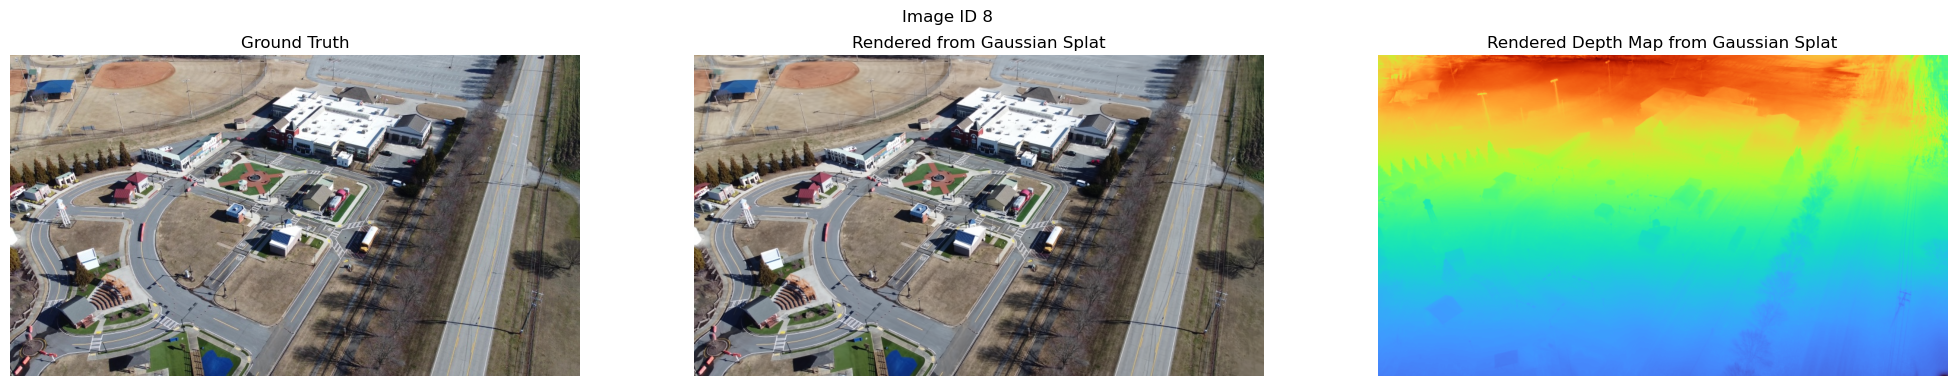

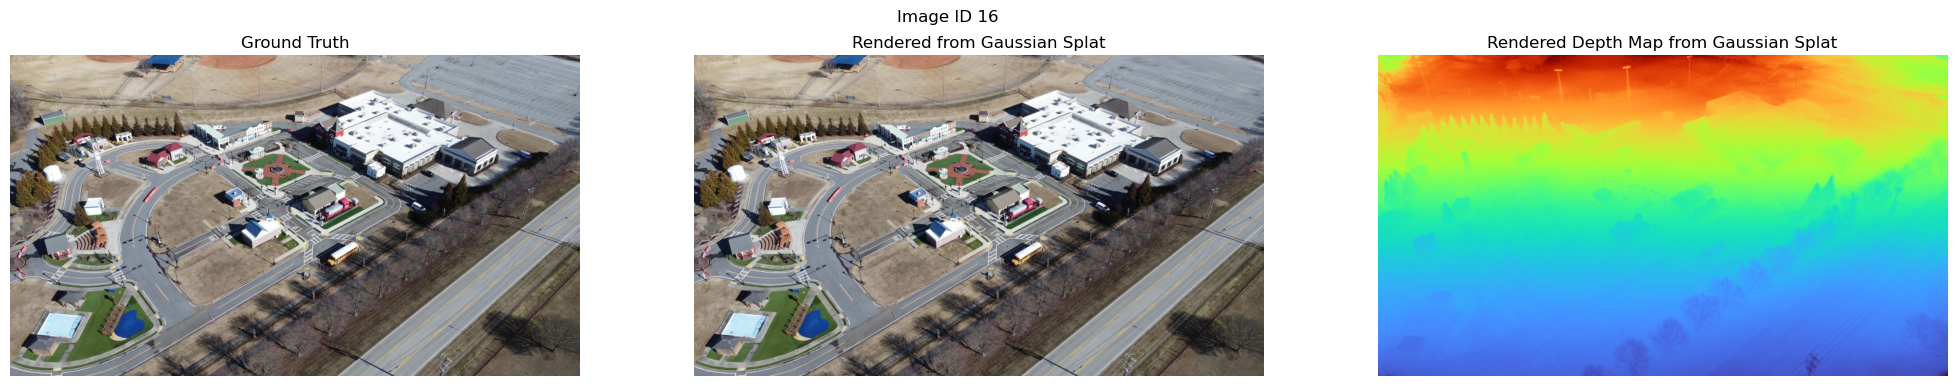

In [8]:
@torch.no_grad()
def plot_reconstruction_results(model: fvdb.GaussianSplat3d, sfm_scene: frc.sfm_scene.SfmScene, image_id: int):
    # Get one of the images and its camera from the scene
    image_meta: frc.sfm_scene.SfmPosedImageMetadata = sfm_scene.images[image_id]
    camera_meta: frc.sfm_scene.SfmCameraMetadata = image_meta.camera_metadata
    camera_to_world_matrix = torch.from_numpy(image_meta.camera_to_world_matrix).to(device=model.device, dtype=torch.float32)
    projection_matrix = torch.from_numpy(camera_meta.projection_matrix).to(device=model.device, dtype=torch.float32)
    image_height, image_width = image_meta.image_size

    # Read the ground truth image from disk
    gt_image = cv2.imread(image_meta.image_path)
    assert gt_image is not None, f"Failed to load image at {image_meta.image_path}"
    gt_image = cv2.cvtColor(gt_image, cv2.COLOR_BGR2RGB)

    # Render the image and a depth map from the Gaussian splat model
    rendered_rgbd, alphas = model.render_images_and_depths(
        world_to_camera_matrices=camera_to_world_matrix.inverse().unsqueeze(0).contiguous(),
        projection_matrices=projection_matrix.unsqueeze(0),
        image_width=image_width,
        image_height=image_height,
        near=0.1,
        far=10000.0,
    )
    rgb = rendered_rgbd[0, ..., :3].cpu().numpy()
    depth = (rendered_rgbd[0, ..., 3] / alphas.squeeze()).cpu().numpy()
    rendered_image = np.clip(rgb, 0.0, 1.0)
    rendered_image = (rendered_image * 255).astype(np.uint8)

    # Plot the ground truth and rendered images side by side
    plt.figure(figsize=(25, 4.25))
    plt.suptitle(f"Image ID {image_id}")
    plt.subplot(1, 3, 1)
    plt.title("Ground Truth")
    plt.axis("off")
    plt.imshow(gt_image)
    plt.subplot(1, 3, 2)
    plt.title("Rendered from Gaussian Splat")
    plt.axis("off")
    plt.imshow(rendered_image)
    plt.subplot(1, 3, 3)
    plt.title("Rendered Depth Map from Gaussian Splat")
    plt.axis("off")
    plt.imshow(depth, cmap="turbo")
    plt.show()

model: fvdb.GaussianSplat3d = runner.model
print(f"Reconstructed Gaussian Splat Model has {model.num_gaussians}, is on device {model.device}, and renders images with {model.num_channels} channels.")
plot_reconstruction_results(model, cleaned_sfm_scene, image_id=8)
plot_reconstruction_results(model, cleaned_sfm_scene, image_id=16)


## Export a Gaussian Splat radiance field to PLY and USDZ
You can save Gaussian Splat models to PLY and USDZ files using `fvdb_reality_capture`. This is useful for exporting your Gaussian Splats to be used in other applications, like [SuperSplat](https://superspl.at/editor/), [Blender with the 3DGS Addon](https://github.com/Kiri-Innovation/3dgs-render-blender-addon), or [NVIDIA's Isaac Sim](https://developer.nvidia.com/isaac/sim). Let's see how to do this below.

Try going to [supersplat.at](https://superspl.at/editor/) and dragging the PLY saved below to try it out.

In [9]:
from fvdb_reality_capture.tools import export_splats_to_usdz

# Save the model as a PLY file for viewing in external tools like SuperSplat
model.save_ply("reconstructed_model.ply", metadata=runner.reconstruction_metadata)

# Save the model as a USDZ file for viewing in tools like NVIDIA's Isaac Sim
export_splats_to_usdz(model, out_path="reconstructed_model.usdz")

2025-10-19 17:42:54,717 - fvdb_reality_capture.tools._export_splats_to_usdz - INFO - Creating USD file containing NuRec model
2025-10-19 17:42:54,775 - fvdb_reality_capture.tools._export_splats_to_usdz - INFO - Model bounding box: min=[-184.37056 -157.57402  -40.16857], max=[165.56892 198.76385  88.72124]
2025-10-19 17:42:54,985 - fvdb_reality_capture.tools._export_splats_to_usdz - INFO - USDZ file created successfully at reconstructed_model.usdz


## Reconstruct a mesh from a Gaussian Splat radiance field

Our Gaussian splat model is capable of producing images and depths from novel views. A natural way to reconstruct a mesh from a Gaussian scene is by rendering depth maps from the camera poses used to reconstruct the model and fuse them into a truncated signed distance field (TSDF) using the TSDF fusion algorithm<sup>[\[2\]](#references)</sup>. 

TSDF fusion accumulates noisy depth maps into a voxel grid, to approximate a signed distance field near the surface of the object. `fvdb_reality_capture` makes use of `fvdb-core` to provide a high performance implementation of TSDF integration on sparse voxels. This allows us to generate meshes from Gaussian splats at very high resolutions on the GPU while using minimal memory.

Let's see how to reconstruct a mesh using the `fvdb_reality_capture.tools` module.


In [10]:
from fvdb_reality_capture.tools import mesh_from_splats
import point_cloud_utils as pcu

# The truncation margin determines the width of the narrow band around the surface in which we compute the TSDF.
# A larger margin will produce coarser voxels, while a smaller margin will produce finer voxels but may miss some surface details.
# Here we pick a truncation margin of 0.25 world units in our scene.
truncation_margin = 0.5

# This function returns a tensor of vertices, faces, and colors for the mesh.
# The vertices have shape (num_vertices, 3), the faces have shape (num_faces, 3),
# and the colors have shape (num_vertices, 3). The colors are in the range [0, 1].
v, f, c = mesh_from_splats(model, cleaned_sfm_scene.camera_to_world_matrices, cleaned_sfm_scene.projection_matrices, cleaned_sfm_scene.image_sizes, truncation_margin)

# Save the mesh as a PLY file for viewing in external tools using point_cloud_utils (https://fwilliams.info/point-cloud-utils/) [3]
pcu.save_mesh_vfc("reconstructed_mesh.ply", v.cpu().numpy(), f.cpu().numpy(), c.cpu().numpy())

print(f"Reconstructed mesh with {v.shape[0]:,} vertices and {f.shape[0]:,} faces")

Extracting TSDF:   0%|          | 0/124 [00:00<?, ?imgs/s, accumulated_voxels=2.53e+7]

Extracting TSDF: 100%|██████████| 124/124 [00:07<00:00, 16.14imgs/s, accumulated_voxels=1.48e+8]


Reconstructed mesh with 12,288,540 vertices and 19,493,229 faces


Note how the final voxel count for tsdf fusion was over 140 million! The sparse TSDF fusion in fvdb, can handle large voxel sizes.

If you open the saved mesh in your favorite editor you get something like this:

<div>
<img src="https://fvdb-data.s3.us-east-2.amazonaws.com/fvdb-reality-capture/doc_figures/worse_mesh_recon.png" width="100%"/>
</div>
This looks good from far, but is far from good. The depth maps produced by Gaussian splats are generally pretty noisy. The result is that the TSDF fusion algorithm produces a bumpy surface like the one in the image above. Fortunately, we can do better, by estimating better depth maps from our splats.

`fvdb_reality_capture.tools` provides a `mesh_from_splats_dlnr` which will use a foundation model to compute high quality depth maps from images rendered from our Gaussian splat. 
The method works by rendering stereo pairs from the splat scene, and uses the DLNR foundation model<sup>[\[4\]](#references)</sup> to perform stereo depth estimation. The DLNR model is a high-frequency stereo matching network that computes optical flow and disparity maps between two images
This method is generally slower to run since you have to evaluate a big neural network to estimate depth for each image, but produces much cleaner results.

Let's see how to use this function to do mesh reconstruction:

In [11]:
from fvdb_reality_capture.tools import mesh_from_splats_dlnr
import point_cloud_utils as pcu

# The truncation margin determines the width of the narrow band around the surface in which we compute the TSDF.
# A larger margin will produce coarser voxels, while a smaller margin will produce finer voxels but may miss some surface details.
# Here we pick a truncation margin of 0.25 world units in our scene.
truncation_margin = 0.5

# This function has virtually the same interface as `mesh_from_splats`.
# It returns a tensor of vertices, faces, and colors for the mesh.
# The vertices have shape (num_vertices, 3), the faces have shape (num_faces, 3),
# and the colors have shape (num_vertices, 3). The colors are in the range [0, 1].
v, f, c = mesh_from_splats_dlnr(model, cleaned_sfm_scene.camera_to_world_matrices, cleaned_sfm_scene.projection_matrices, cleaned_sfm_scene.image_sizes, truncation_margin)

# Save the mesh as a PLY file for viewing in external tools using point_cloud_utils (https://fwilliams.info/point-cloud-utils/) [3]
pcu.save_mesh_vfc("reconstructed_mesh_dlnr.ply", v.cpu().numpy(), f.cpu().numpy(), c.cpu().numpy())

print(f"Reconstructed mesh with {v.shape[0]:,} vertices and {f.shape[0]:,} faces")

2025-10-19 17:43:05,507 - fvdb_reality_capture.foundation_models.dlnr.DLNRModel - INFO - Loading DLNR pretrained weights from /home/fwilliams/projects/openvdb/fvdb-reality-capture/fvdb_reality_capture/foundation_models/_weights/middlebury_dlnr.pth
2025-10-19 17:43:05,859 - fvdb_reality_capture.foundation_models.dlnr.DLNRModel - INFO - DLNR model loaded successfully.
Generating DLNR Depths:   0%|          | 0/124 [00:00<?, ?imgs/s]/home/fwilliams/bin/miniconda3/envs/fvdb/lib/python3.12/site-packages/torch/nn/functional.py:5096: UserWarning: Default grid_sample and affine_grid behavior has changed to align_corners=False since 1.3.0. Please specify align_corners=True if the old behavior is desired. See the documentation of grid_sample for details.
  warnings.warn(
Extracting TSDF: 100%|██████████| 124/124 [00:07<00:00, 16.88imgs/s, accumulated_voxels=5.98e+7]


Reconstructed mesh with 8,444,464 vertices and 14,809,696 faces


If you open the saved mesh in your favorite editor, you'll see something like this. Much better! 
Details are preserved, and there isn't much noise in the reconstruction. In general, if you can afford the weight, you should stick to `fvdb_reality_capture.tools.mesh_from_splats_dlnr` for high quality mesh reconstructions.

<div>
<img src="https://fvdb-data.s3.us-east-2.amazonaws.com/fvdb-reality-capture/doc_figures/better_mesh_recon.png" width="100%"/>
</div>

## References
* _\[1\] Kerbl, Kopanas et.al. - ["3D Gaussian Splatting
for Real-Time Radiance Field Rendering"](https://repo-sam.inria.fr/fungraph/3d-gaussian-splatting/)_
* _\[2\] Newcombe et.al. - ["KinectFusion: Real-Time Dense Surface Mapping and Tracking"](https://www.microsoft.com/en-us/research/wp-content/uploads/2016/02/ismar2011.pdf)_
* _\[3\] Williams - [Point Cloud Utils](https://fwilliams.info/point-cloud-utils/)_
* _\[4\] Zhao, Zhou et.al. - [High Frequency Stereo Matching](https://openaccess.thecvf.com/content/CVPR2023/papers/Zhao_High-Frequency_Stereo_Matching_Network_CVPR_2023_paper.pdf)_